<a href="https://colab.research.google.com/github/ChrissGeorgiou/DatabasesAnalyticsCHRcoursework/blob/main/NorthstarRcoursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing packagaes in this section

In [18]:
install.packages("sqldf")
install.packages("readr")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Datasets

In [19]:
library(sqldf)
library(readr)

customers <- read_csv("/content/customers.csv")
orders <- read_csv("/content/orders.csv")
deliveries <- read_csv("/content/deliveries.csv")
drivers <- read_csv("/content/drivers.csv")
vehicles   <- read_csv("/content/vehicles.csv")
incidents  <- read_csv("/content/incidents.csv")
complaints <- read_csv("/content/complaints.csv")
hubs       <- read_csv("/content/hubs.csv")
app_events <- read_csv("/content/app_events.csv")


Rows: 650 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (3): age, loyalty_score, app_engagement_score
dttm (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6)

Calling dataset

In [20]:
cat("customers:", nrow(customers), "\n")
cat("orders:", nrow(orders), "\n")
cat("deliveries:", nrow(deliveries), "\n")
cat("drivers:", nrow(drivers), "\n")
cat("vehicles:", nrow(vehicles), "\n")
cat("incidents:", nrow(incidents), "\n")
cat("complaints:", nrow(complaints), "\n")
cat("hubs:", nrow(hubs), "\n")
cat("app_events:", nrow(app_events), "\n")

customers: 650 
orders: 1250 
deliveries: 950 
drivers: 170 
vehicles: 120 
incidents: 280 
complaints: 320 
hubs: 8 
app_events: 640 


Q1 Which zones have the most failed deliveries?



In [21]:
deliveries$delivery_status <- trimws(tolower(deliveries$delivery_status))

zone_failures <- sqldf("
  SELECT pickup_zone AS zone,
         COUNT(*) AS total_deliveries,
         SUM(CASE WHEN delivery_status = 'failed' THEN 1 ELSE 0 END) AS failed,
         ROUND(SUM(CASE WHEN delivery_status = 'failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate_pct
  FROM deliveries
  JOIN orders USING(order_id)
  GROUP BY pickup_zone
  ORDER BY failure_rate_pct DESC
")

print(zone_failures)




        zone total_deliveries failed failure_rate_pct
1  RiverSide               66     14            21.21
2    Central               55     11            20.00
3    CENTRAL               55     11            20.00
4      North               37      7            18.92
5        Ctr               64     11            17.19
6      north               52      8            15.38
7      NORTH               46      7            15.22
8       EAST               78     11            14.10
9       West               51      7            13.73
10     South               83     10            12.05
11   Airport               67      8            11.94
12      WEST               63      7            11.11
13      East               78      8            10.26
14   AIRPORT               46      4             8.70
15 Riverside               53      4             7.55
16     SOUTH               56      4             7.14


Q2 Which drivers have the worst ratings?

In [22]:
driver_performance <- sqldf("
  SELECT driver_id, driver_rating, training_score, years_experience, base_zone
  FROM drivers
  WHERE active_flag = 1
  ORDER BY driver_rating ASC
  LIMIT 10
")

print(driver_performance)

   driver_id driver_rating training_score years_experience base_zone
1       D095          3.15           99.0               12      WEST
2       D128          3.32           84.7               13   Central
3       D024          3.35           71.4                8 RiverSide
4       D022          3.36           68.7                9      EAST
5       D042          3.37           70.5                9     North
6       D052          3.39           71.7                8 Riverside
7       D141          3.44           71.4               14     North
8       D048          3.45           76.3                7      East
9       D104          3.45           87.7               15      WEST
10      D099          3.48           82.7               10     NORTH


Q3: Average compensation by complaint type

In [23]:
complaint_analysis <- sqldf("
  SELECT complaint_type,
         COUNT(*) AS total_complaints,
         ROUND(AVG(compensation_amount), 2) AS avg_compensation,
         ROUND(AVG(resolution_days), 2) AS avg_resolution_days
  FROM complaints
  GROUP BY complaint_type
  ORDER BY avg_compensation DESC
")

print(complaint_analysis)

     complaint_type total_complaints avg_compensation avg_resolution_days
1            Damage               15            23.98               11.33
2           Billing               16            23.87                7.75
3      MissedPickup               64            22.59                7.64
4   DriverBehaviour               51            21.15                8.16
5          AppIssue               53            19.61                8.60
6             Delay              101            18.05                7.26
7 SupportExperience               20            17.13                7.45


Q4 Vehicle Maintenance Status vs incidents

In [24]:
vehicle_incidents <- sqldf("
  SELECT maintenance_status,
         COUNT(DISTINCT vehicles.vehicle_id) AS total_vehicles,
         COUNT(incident_id) AS total_incidents,
         ROUND(AVG(battery_health_pct), 2) AS avg_battery_health
  FROM vehicles
  LEFT JOIN deliveries ON vehicles.vehicle_id = deliveries.vehicle_id
  LEFT JOIN incidents ON deliveries.delivery_id = incidents.delivery_id
  GROUP BY maintenance_status
  ORDER BY total_incidents DESC
")

print(vehicle_incidents)

  maintenance_status total_vehicles total_incidents avg_battery_health
1             Active             67             150              76.40
2           InRepair             36              84              76.41
3          Scheduled             17              46              78.70


Q5 Most Unprofitable orders

In [25]:
failed_high_value <- sqldf("
  SELECT orders.order_id, order_value, delivery_status,
         fuel_or_charge_cost, manual_route_override_count
  FROM orders
  JOIN deliveries ON orders.order_id = deliveries.order_id
  WHERE delivery_status = 'failed'
  ORDER BY order_value DESC
  LIMIT 10
")

print(failed_high_value)

   order_id order_value delivery_status fuel_or_charge_cost
1    O01207      321.68          failed               16.98
2    O01112      278.14          failed               16.82
3    O00173      249.32          failed                9.05
4    O00919      229.93          failed               11.11
5    O01143      217.11          failed               13.94
6    O00585      215.96          failed               13.31
7    O00035      209.07          failed                9.20
8    O00081      208.38          failed                9.08
9    O00536      204.12          failed               11.56
10   O00921      198.22          failed                6.59
   manual_route_override_count
1                            3
2                            1
3                            1
4                            1
5                            0
6                            0
7                            0
8                            1
9                            3
10                           0

SUMMARY
Riverside and centralzones have highest delivery failure rates(21% and 20%
Inoncistent zone naming across the dataset
Driver D095 has the lowest rating(3.15) despite 12 years of experience
Damage Complaints are the most expensive(23.98 compensation)
Delay is the most frequent complaint type
Active behicles have the most incidents, meaning maintenance is reactive not preventive
Several high-value orders failed , representing major revenue loss

**SECTION 2 **

Clean zone names for grouping

In [26]:
library(ggplot2)
deliveries$delivery_status <- trimws(tolower(deliveries$delivery_status))
orders$pickup_zone <- trimws(tolower(orders$pickup_zone))

merge deliveries with orders to get zone info

In [27]:
merged <- merge(deliveries, orders, by = "order_id")

failure rate by zone

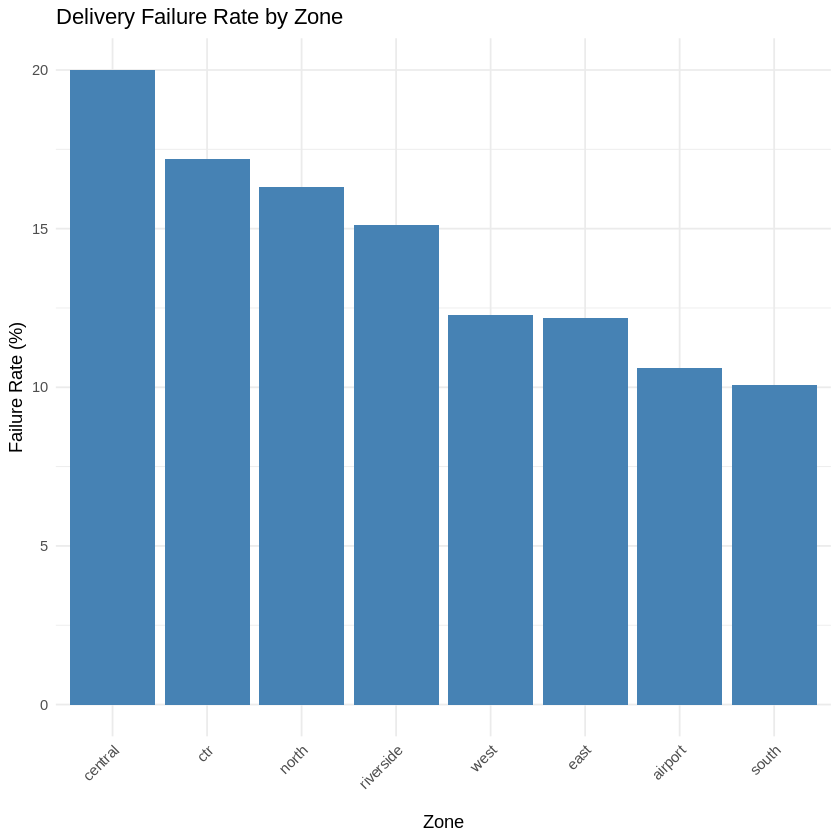

In [28]:
zone_summary <- aggregate(
  cbind(failed = delivery_status == "failed") ~ pickup_zone,
  data = merged,
  FUN = mean
)
zone_summary$failure_rate <- round(zone_summary$failed * 100, 2)

ggplot(zone_summary, aes(x = reorder(pickup_zone, -failure_rate), y = failure_rate)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  labs(title = "Delivery Failure Rate by Zone", x = "Zone", y = "Failure Rate (%)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

merge drivers with deliveries

In [29]:
driver_merged <- merge(deliveries, drivers, by = "driver_id")
driver_merged$failed <- ifelse(driver_merged$delivery_status == "failed", 1, 0)

Correlation between score and failre and scatter plot


Correlation between training score and delivery failure: 0.061 


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 40 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 40 rows containing missing values or values outside the scale range
(`geom_point()`).”


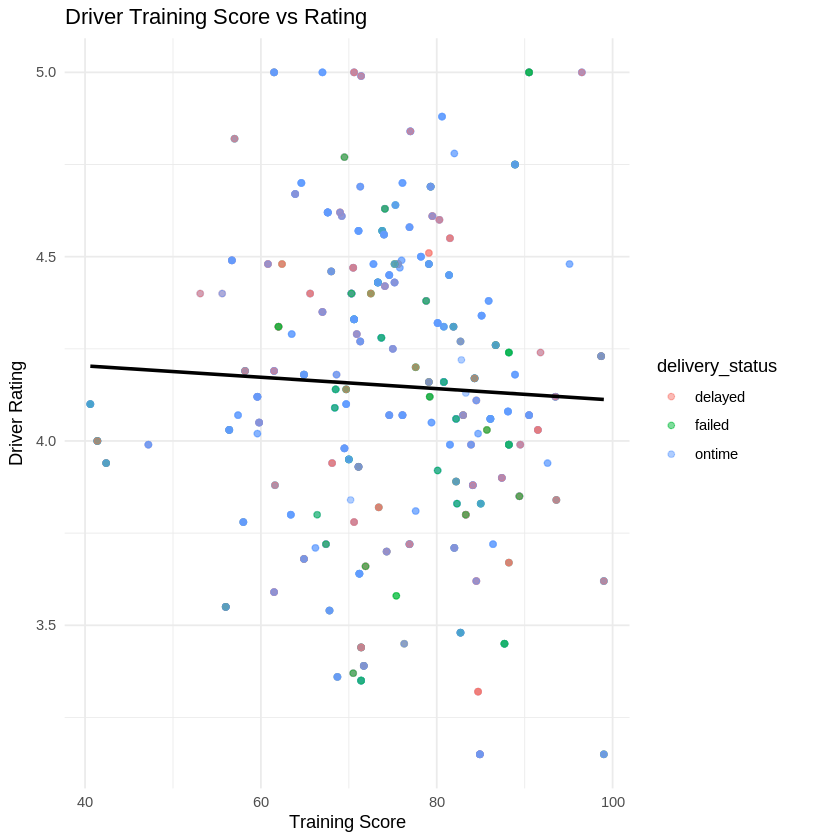

In [30]:
cor_val <- cor(driver_merged$training_score, driver_merged$failed, use = "complete.obs")
cat("Correlation between training score and delivery failure:", round(cor_val, 3), "\n")

# scatter plot
ggplot(driver_merged, aes(x = training_score, y = driver_rating)) +
  geom_point(aes(color = delivery_status), alpha = 0.5) +
  geom_smooth(method = "lm", se = FALSE, color = "black") +
  labs(title = "Driver Training Score vs Rating",
       x = "Training Score", y = "Driver Rating") +
  theme_minimal()

Complaint severity distribution by type

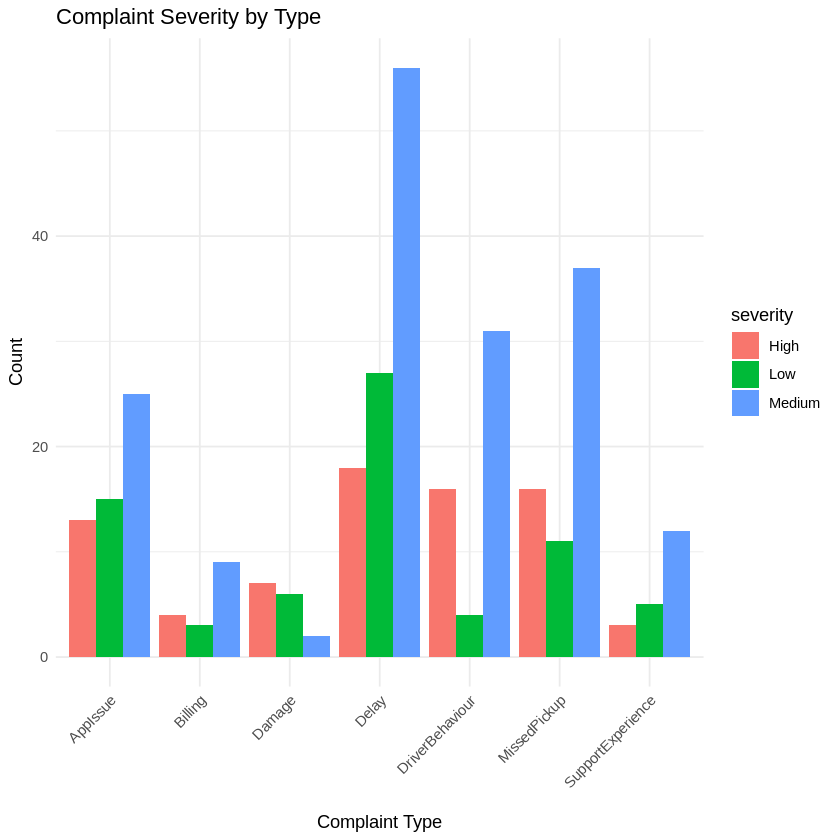

In [32]:
ggplot(complaints, aes(x = complaint_type, fill = severity)) +
  geom_bar(position = "dodge") +
  labs(title = "Complaint Severity by Type", x = "Complaint Type", y = "Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))